In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict.csv
/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict_Ver1.1.csv


In [2]:
df=pd.read_csv('/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict_Ver1.1.csv')

In [3]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [5]:
df.shape

(500, 9)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [7]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop(columns=['Serial No.'] ,inplace=True)

In [11]:
df.head(2)

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76


In [12]:
x=df.iloc[:,0:-1]
y=df.iloc[:,-1]


In [14]:
y

0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
495    0.87
496    0.96
497    0.93
498    0.73
499    0.84
Name: Chance of Admit , Length: 500, dtype: float64

In [15]:
x

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1
496,337,117,5,5.0,5.0,9.87,1
497,330,120,5,4.5,5.0,9.56,1
498,312,103,4,4.0,5.0,8.43,0


In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2 , random_state=3)

In [17]:
x_train

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
280,311,102,3,4.5,4.0,8.64,1
190,324,111,5,4.5,4.0,9.16,1
103,317,104,2,4.5,4.0,8.47,0
201,315,110,2,3.5,3.0,8.46,1
402,324,109,3,3.5,3.0,8.94,1
...,...,...,...,...,...,...,...
440,305,104,2,2.5,1.5,7.79,0
131,303,105,5,5.0,4.5,8.65,0
249,321,111,3,3.5,4.0,8.83,1
152,321,112,5,5.0,5.0,9.06,1


In [18]:
from sklearn.preprocessing import MinMaxScaler
sc=MinMaxScaler()

x_train_sc=sc.fit_transform(x_train)
x_test_sc=sc.transform(x_test)

In [20]:
x_train_sc

array([[0.42      , 0.35714286, 0.5       , ..., 0.75      , 0.58974359,
        1.        ],
       [0.68      , 0.67857143, 1.        , ..., 0.75      , 0.75641026,
        1.        ],
       [0.54      , 0.42857143, 0.25      , ..., 0.75      , 0.53525641,
        0.        ],
       ...,
       [0.62      , 0.67857143, 0.5       , ..., 0.75      , 0.65064103,
        1.        ],
       [0.62      , 0.71428571, 1.        , ..., 1.        , 0.72435897,
        1.        ],
       [0.96      , 0.82142857, 1.        , ..., 1.        , 0.77884615,
        1.        ]])

In [22]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from keras.layers import Dense

In [43]:
model=Sequential()

model.add(Dense(7,activation='relu' , input_dim=7))
model.add(Dense(7,activation='relu'))
model.add(Dense(1,activation='linear'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.compile(loss='mean_squared_error', optimizer='Adam')

In [47]:
hist=model.fit(x_train_sc,y_train, epochs=120, validation_split=0.2)

Epoch 1/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.3079 - val_loss: 0.2644
Epoch 2/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2253 - val_loss: 0.1883
Epoch 3/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1632 - val_loss: 0.1358
Epoch 4/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1192 - val_loss: 0.0965
Epoch 5/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0854 - val_loss: 0.0661
Epoch 6/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0595 - val_loss: 0.0440
Epoch 7/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0409 - val_loss: 0.0289
Epoch 8/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0287 - val_loss: 0.0192
Epoch 9/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0209 - val_loss: 0.0136
Epoch 10/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0165 - val_loss: 0.0107
Epoch 11/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0140 - val_loss: 0.0094
Epoch 12/120
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0

In [48]:
y_pred=model.predict(x_test_sc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


In [49]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.7641278003360576

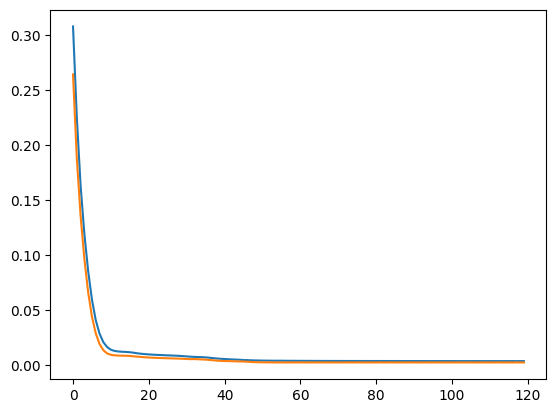

In [50]:
import matplotlib.pyplot as plt
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])